In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
%cd /content/drive/MyDrive/인공지능사관학교/성장과정/랭체인

/content/drive/MyDrive/인공지능사관학교/성장과정/랭체인


In [3]:
!pip install -qU langchain langchain-openai langchain-community langchain-experimental
!pip install -qU langchain-chroma faiss-cpu langchain-teddynote
!pip install -qU langchain-tavily google-search-results pypdf
!pip install -qU mypy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.9/136.9 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.2/211.2 kB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 54.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 558.3/558.3 kB 37.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 60.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 6.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.
     ━━━━━━━━━━━━━

In [4]:
import os
from uuid import uuid4

# 타입 설정
# Sequence : 메시지들의 순서 있는 시퀀스(리스트) 객체 (list 또는 tuple 형태로 메시지를 저장)
# Literal : 값 자체를 타입으로 제한할 수 있도록 해주는 기능
from typing import Annotated, TypedDict, Dict, List, Sequence, Literal
# pydantic : Python 데이터 검증과 설정 관리를 위한 라이브러리
from pydantic import Field, BaseModel, ValidationError

# 상태, 노드
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, START, END
# 도구를 노드로 만드는 기능 (자동 맵핑, 상태업데이트, 다중 실행)
from langgraph.prebuilt import ToolNode
# 도구 노드의 결과에 따라 자동으로 라우팅 경로를 설정
from langgraph.prebuilt import tools_condition

# 메모리 저장소
from langgraph.checkpoint.memory import MemorySaver

# 실행 설정
from langchain_core.runnables import RunnableConfig

# 시각화
from IPython.display import Image, display, Markdown
from langchain_teddynote.messages import stream_graph

# 모델 설정
from langchain.chat_models import init_chat_model
from langchain_core.prompts import ChatPromptTemplate, PromptTemplate, MessagesPlaceholder
# BaseMessage : BaseMessage를 상속한 다양한 메시지 타입 (HumanMessage, AIMessage, SystemMessage)
from langchain_core.messages import HumanMessage, AIMessage, BaseMessage

# 웹 검색 도구
from langchain_community.tools.tavily_search import TavilySearchResults
#from langchain_tavily import TavilySearch

# 도구 정의 데코레이터
from langchain.tools import tool

# RAG 라이브러리
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings

from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser

/tmp/ipykernel_636/2493808475.py:36: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools.tavily_search import TavilySearchResults


In [5]:
# OpenAI Key 환경변수설정
with open("./key/openai_key.txt", "r") as f:
    api_key = f.read().strip()

os.environ['OPENAI_API_KEY'] = api_key

In [6]:
with open("./key/tavily_key.txt", "r") as f:
    api_key = f.read().strip()

os.environ['TAVILY_API_KEY'] = api_key

## 적응형 RAG 시스템 아키텍처

### 기본 PDF기반 백터스토어 준비

In [181]:
# 문서로드
loader = PyPDFLoader("./data/SPRi AI Brief_11월호산업동향.pdf")
documents = loader.load()

#청킹
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size = 500,
    chunk_overlap = 50
)
texts = text_splitter.split_documents(documents)

# 백터 DB 생성 및 검색기 설정
vec_db = FAISS.from_documents(texts, OpenAIEmbeddings())
retriever = vec_db.as_retriever(search_kwargs={"k": 5})

### Query분석을 위한 Router 만들기

In [8]:
# query와 DB index의 관계를 이진분류하도록 구성
#  관련성이 있으면 vectorstore 없으면 web_search로 나오도록 구성
class RouteQueryResult(BaseModel):
  '''사용자 쿼리를 가장 관련성이 높은 데이터소스로 라우팅'''
  datasource : Literal['vectorstore', 'web_search'] = Field(
      ..., # 필수입력 요소
      description = "사용자 질문이 주어지면 웹 검색이나 백터스토어로 라우팅하도록 선택하세요"
  )

In [9]:
# 지정된 조건에 맞춰서 생성되야 에러 없음
RouteQueryResult(datasource="vectorstore")

RouteQueryResult(datasource='vectorstore')

In [10]:
 # 시스템 메시지와 사용자 질문을 포함한 프롬프트 템플릿 생성
system = """당신은 사용자 질문을 벡터스토어나 웹 검색으로 라우팅하는 전문가입니다.
벡터스토어에는 SPRI AI Bried 11월호 산업동향 관련 문서가 포함되어 있습니다. 주제들은 다음과 같다.
- 미국 민권위원회, 연방정부의 얼굴인식 기술 사용에 따른 민권 영향 분석
- 미국 백악관 예산관리국, 정부의 책임 있는 AI 조달을 위한 지침 발표
- 유로폴, 법 집행에서 AI의 이점과 과제를 다룬 보고서 발간 ·
- OECD, 공공 부문의 AI 도입을 위한 G7 툴킷 발표
- 세계경제포럼, 생성AI 시대의 거버넌스 프레임워크 제시
- CB인사이츠 분석 결과, 2024년 3분기 벤처 투자 31%가 AI 스타트업에 집중
- 메타, 동영상 생성AI 도구 ‘메타 무비 젠’ 공개
- 메타, 이미지와 텍스트 처리하는 첫 멀티모달 AI 모델 ‘라마 3.2’ 공개
- 앨런AI연구소, 벤치마크 평가에서 GPT-4o 능가하는 성능의 오픈소스 LLM ‘몰모’ 공개
- 미스트랄AI, 온디바이스용 AI 모델 ‘레 미니스트로’ 공개
- 카카오, 통합 AI 브랜드 겸 신규 AI 서비스 ‘카나나’ 공개
- 2024년 노벨 물리학상과 화학상, AI 관련 연구자들이 수상
- 미국 국무부, AI 연구에서 국제협력을 위한 ‘글로벌 AI 연구 의제’ 발표
- 일본 AI안전연구소, AI 안전성에 대한 평가 관점 가이드 발간
- 구글 딥마인드, 반도체 칩 레이아웃 설계하는 AI 모델 ‘알파칩’ 발표
- AI21 CEO, AI 에이전트에 트랜스포머 아키텍처의 대안 필요성 강조
- MIT 산업성과센터, 근로자 관점에서 자동화 기술의 영향 조사
- 다이스 조사, AI 전문가의 73%는 2025년 중 이직 고려
- 가트너 예측, AI로 인해 엔지니어링 인력의 80%가 역량 향상 필요
- 인디드 조사 결과, 생성AI가 인간 근로자 대체할 가능성은 희박

이러한 주제에 대한 질문이 있으면 벡터스토어를 사용하세요. 그렇지 않으면 웹 검색을 사용하십시오."""

In [11]:
# 템플릿 생성
route_template = ChatPromptTemplate.from_messages(
    [
        ('system', system),
        ('human', '{query}')
    ]
)
# 모델 생성
llm = init_chat_model(model="openai:gpt-4o-mini")
# 체인 구성하기
question_router = route_template | llm.with_structured_output(RouteQueryResult)

In [12]:
# 테스트
print(question_router.invoke("오늘 점심메뉴 추천해줘"))

datasource='web_search'


In [13]:
# 테스트
print(question_router.invoke("2024년 노벨 물리학상과 화학상 수상자 알려줘"))

datasource='vectorstore'


### 검색 평가기 (Retrieval Grader)

In [14]:
# 문서평가를 위한 데이터 모델 정의
class RetrievalGradeResult(BaseModel):
  '''검색된 문서에 대한 관련성 검사결과'''
  binary_score: Literal['yes', 'no'] = Field(
      ... ,
      description="문서가 질문과 관련이 있으면 'yes'로 응답하고 그렇지 않으면 'no'로 응답"
  )


In [15]:
# 시스템 메시지와 사용자 질문을 포함한 프롬프트 템플릿 생성
system = """당신은 검색된 문서와 사용자 질문의 관련성을 평가하는 채점자입니다. \n
    문서에 사용자 질문과 관련된 키워드 또는 의미적 의미가 포함되어 있는 경우 관련성 있는 것으로 평가합니다. \n
    엄격한 테스트일 필요는 없습니다. 목표는 잘못된 검색을 필터링하는 것입니다. \n
    문서가 질문과 관련이 있는지 여부를 나타내기 위해 이진 점수 'yes' 또는 'no' 점수를 부여합니다."""

In [16]:
# 탬플릿 생성
retrieval_grader_template = ChatPromptTemplate.from_messages(
    [
        ('system', system),
        ('human', '사용자 질문: {query} \n\n 검색된 문서: \n\n {documents}')
    ]
)
# 모델 생성
llm = init_chat_model(model='openai:gpt-4o-mini')
# 체인 구성하기
retrieval_grader_chain = retrieval_grader_template | llm.with_structured_output(RetrievalGradeResult)

In [17]:
# 테스트
q1 = "카카오가 만든 통합 AI브랜드 겸 신규 AI서비스의 이름?"
q2 = "삼성전자가 만든 생성형 AI의 이름은?"

In [18]:
# 질문에 관련된 문서 검색
docs = retriever.invoke(q1)
# 문서내용 추출 후 체인 호출
rs1 = retrieval_grader_chain.invoke({'query': q1, 'documents': docs[0].page_content})

In [19]:
rs1

RetrievalGradeResult(binary_score='yes')

In [20]:
docs[0].page_content

'1. 정책/법제  2. 기업/산업 3. 기술/연구  4. 인력/교육\n11\n카카오, 통합 AI 브랜드 겸 신규 AI 서비스 ‘카나나’ 공개n카카오가 대화의 맥락 속에서 주요 정보를 기억해 이용자에게 최적화된 답변을 제공하는 AI 메이트 서비스인 ‘카나나’를 공개 했으며 카카오톡과 별개의 앱으로 출시 예정n카카오는 자체 언어모델로 용량 별로 카나나 플래그, 카나나 에센스, 카나나 나노도 개발 중으로, 에센스와 나노를 중심으로 주요 서비스에 적용할 계획 \nKEY Contents'

In [21]:
# 질문에 관련된 문서 검색
docs = retriever.invoke(q2)
# 문서내용 추출 후 체인 호출
rs2 = retrieval_grader_chain.invoke({'query': q2, 'documents': docs[0].page_content})

In [22]:
rs2

RetrievalGradeResult(binary_score='no')

In [23]:
docs[0].page_content

'£AI 에이전트 활성화를 위해 향상된 메모리 성능을 갖춘 대체 아키텍처 채택 필요n이스라엘의 AI 스타트업 AI21의 오리 고센(Ori Goshen) CEO가 AI 에이전트를 활성화하려면 트랜스포머(Transformer)* 이외의 새로운 아키텍처**가 필요하다고 주장* 문장 속 단어와 같은 순차 데이터 내의 관계를 추적해 맥락과 의미를 학습하는 신경망 ** AI 시스템이 데이터를 처리하고 학습하기 위한 신경망의 전체적인 구조와 설계 방식을 의미 ∙트랜스포머는 현재 AI 모델 개발에서 가장 많이 사용되는 아키텍처이지만, 다중 에이전트 생태계 조성 측면에서는 한계를 내포∙트랜스포머 아키텍처는 처리하는 컨텍스트가 길수록 속도가 느리고 연산 비용이 많이 드는데, AI 에이전트는 LLM을 여러 차례 호출해야 하고 각 단계에서 광범위한 컨텍스트를 사용하는 경우가 많아 처리 과정에서 지연이 발생n고센 CEO는 ‘맘바(Mamba)’와 ‘잠바(Jamba)’와 같은 대체 아키텍처를 활용하면 AI'

### 답변 생성을 위한 RAG 체인 구성

In [24]:
 # 시스템 메시지와 사용자 질문을 포함한 프롬프트 템플릿 생성
system_template = """당신은 검색 증강 생성(RAG) 시스템 내에서 질문 답변(QA) 작업을 전문으로 하는 AI 보조자입니다.
당신의 주요 임무는 제공된 컨텍스트 또는 채팅 기록을 기반으로 질문에 답변하는 것입니다.
답변이 간결하고 추가 설명 없이 질문에 직접적으로 답하는지 확인하세요.

###

최종 답변은 간결하게 작성해야 하며(단, 중요한 숫자 값, 기술 용어, 전문 용어 및 이름 포함) 정보 출처를 기재해야 합니다.

# 처리 단계

1. 제공된 맥락을 주의 깊게 읽고 이해합니다.
2. 문맥 내에서 질문과 관련된 주요 정보를 식별합니다.
3. 관련 정보를 바탕으로 간결한 답변을 작성합니다.
4. 최종 답변이 질문에 직접적으로 관련되어 있는지 확인하세요.
5. 답변의 출처를 글머리 기호로 나열하십시오. 파일 이름(페이지 번호 포함) 또는 문맥의 URL이어야 합니다. 출처를 찾을 수 없으면 생략하세요.

# 출력 형식:
[숫자 값, 기술 용어, 전문 용어 및 원래 언어의 이름이 포함된 최종 답변이 여기에 있습니다.]

**Source**
- (관련성 있는 예시문장 3줄이내로 표기 필수)
- (답변의 출처는 파일 이름(페이지 번호 포함) 또는 컨텍스트의 URL이어야 합니다. 답변의 출처를 찾을 수 없으면 생략하세요.)
- (소스가 여러 개인 경우 리스트를 사용하여 추가)

###

주의점:
- **제공된 컨텍스트**만을 토대로 답변을 작성하는 것이 중요합니다..
- 주어진 자료에 없는 외부 지식이나 정보를 사용하지 마십시오.
- 답변의 출처를 찾을 수 없으면 모른다고 대답해야 합니다..

###

# 귀하가 대답해야 할 사용자의 질문은 다음과 같습니다.:
{question}

# 질문에 답하기 위해 사용해야 하는 CONTEXT는 다음과 같습니다.:
{context}
"""

In [25]:
# 프롬프트 템플릿 구성
RAG_template = ChatPromptTemplate.from_messages(
    [
        ('system', system_template)
    ]
)
# LLM 생성
llm = init_chat_model(model='openai:gpt-4o-mini')
# chain 구성
rag_chain = RAG_template | llm | StrOutputParser()

In [26]:
# 테스트
q1 = "카카오가 만든 통합 AI 브랜드 겸 신규 AI서비스의 이름은?"
docs = retriever.invoke(q1)
docs_list = "\n\n".join([doc.page_content for doc in docs])
docs_list

'1. 정책/법제  2. 기업/산업 3. 기술/연구  4. 인력/교육\n11\n카카오, 통합 AI 브랜드 겸 신규 AI 서비스 ‘카나나’ 공개n카카오가 대화의 맥락 속에서 주요 정보를 기억해 이용자에게 최적화된 답변을 제공하는 AI 메이트 서비스인 ‘카나나’를 공개 했으며 카카오톡과 별개의 앱으로 출시 예정n카카오는 자체 언어모델로 용량 별로 카나나 플래그, 카나나 에센스, 카나나 나노도 개발 중으로, 에센스와 나노를 중심으로 주요 서비스에 적용할 계획 \nKEY Contents\n\n£카카오의 신규 AI 서비스 ‘카나나’, 개인메이트 ‘나나’와 그룹메이트 ‘카나’로 구현 n카카오가 2024년 10월 22~24일 열린 개발자 컨퍼런스 ‘if(kakaoAI)2024’에서 그룹 전체의 AI 비전과 방향성을 공개하고 통합 AI 브랜드 ‘카나나(Kanana)’를 발표∙사명인 카카오와 함께, ‘나에게 배워 나처럼 생각하고 행동한다’는 의미의 네이티브(Native), ‘배우지 않아도 자연스럽게 사용 가능한 기술’이라는 의미의 내츄럴(Natural) 등의 단어를 조합한 카나나는 ‘가장 나다운 AI’를 의미∙카카오는 동 브랜드를 자사가 개발하는 주요 AI 모델과 신규 서비스의 이름에 두루 사용할 계획으로, AI 메이트 서비스 ‘카나나’ 출시 계획도 공개n카나나는 대화의 맥락 속에서 주요 정보를 기억해 이용자에게 최적화된 답변을 제시하는 ‘AI 메이트’를 지향하며, 개인메이트 ‘나나(nana)’와 그룹메이트 ‘카나(kana)’로 구현∙개인메이트 나나는 이용자와 일대일 대화 및\n\nASI(AI Safety Initiative)’도 강조∙Kakao ASI는 안전하고 윤리적인 AI 기술 개발 및 운영 시스템을 구축하기 위한 종합 지침으로서, 기술의 설계부터 개발, 테스트, 배포, 모니터링, 업데이트 등 AI 시스템의 전 생애주기에서 발생할 수 있는 리스크에 선제적 대응 추구 ☞ 출처: Kakao, 카카오, ‘if(kakaoAI)2024’에서 그룹 AI 비전 공개…AI 메이트 ‘카

In [27]:
# 검색된 결과를 구조화된 문자로 만들어주는 함수(내용, 출처 등)
def format_docs(docs):
  return "\n\n".join([
      f'''
        <document>
          <content>{doc.page_content}</content>
          <source>{doc.metadata['source']}</source>
          <source>{doc.metadata['page']}</source>
        </document>
      '''
      for doc in docs
      ])

In [28]:
# 테스트
q1 = "카카오가 만든 통합 AI 브랜드 겸 신규 AI서비스의 이름은?"
docs = retriever.invoke(q1)
docs_list = format_docs(docs)
docs_list

'\n        <document>\n          <content>1. 정책/법제  2. 기업/산업 3. 기술/연구  4. 인력/교육\n11\n카카오, 통합 AI 브랜드 겸 신규 AI 서비스 ‘카나나’ 공개n카카오가 대화의 맥락 속에서 주요 정보를 기억해 이용자에게 최적화된 답변을 제공하는 AI 메이트 서비스인 ‘카나나’를 공개 했으며 카카오톡과 별개의 앱으로 출시 예정n카카오는 자체 언어모델로 용량 별로 카나나 플래그, 카나나 에센스, 카나나 나노도 개발 중으로, 에센스와 나노를 중심으로 주요 서비스에 적용할 계획 \nKEY Contents</content>\n          <source>./data/SPRi AI Brief_11월호산업동향.pdf</source>\n          <source>13</source>\n        </document>\n      \n\n\n        <document>\n          <content>£카카오의 신규 AI 서비스 ‘카나나’, 개인메이트 ‘나나’와 그룹메이트 ‘카나’로 구현 n카카오가 2024년 10월 22~24일 열린 개발자 컨퍼런스 ‘if(kakaoAI)2024’에서 그룹 전체의 AI 비전과 방향성을 공개하고 통합 AI 브랜드 ‘카나나(Kanana)’를 발표∙사명인 카카오와 함께, ‘나에게 배워 나처럼 생각하고 행동한다’는 의미의 네이티브(Native), ‘배우지 않아도 자연스럽게 사용 가능한 기술’이라는 의미의 내츄럴(Natural) 등의 단어를 조합한 카나나는 ‘가장 나다운 AI’를 의미∙카카오는 동 브랜드를 자사가 개발하는 주요 AI 모델과 신규 서비스의 이름에 두루 사용할 계획으로, AI 메이트 서비스 ‘카나나’ 출시 계획도 공개n카나나는 대화의 맥락 속에서 주요 정보를 기억해 이용자에게 최적화된 답변을 제시하는 ‘AI 메이트’를 지향하며, 개인메이트 ‘나나(nana)’와 그룹메이트 ‘카나(kana)’로 구현∙개인메이트 나나는 이용자와 일대일 대화 및</c

In [29]:
llm_answer1 = rag_chain.invoke({'question':q1, 'context':docs_list})
llm_answer1

'카카오가 만든 통합 AI 브랜드 겸 신규 AI 서비스의 이름은 \'카나나(Kanana)\'입니다.\n\n**Source**\n- "카카오는 동 브랜드를 자사가 개발하는 주요 AI 모델과 신규 서비스의 이름에 두루 사용할 계획으로, AI 메이트 서비스 ‘카나나’ 출시 계획도 공개." \n- "./data/SPRi AI Brief_11월호산업동향.pdf"'

### 환각검사 평가기 (Hallucination Grader)

- 환각 검사 결과 모델

In [30]:
class HallucinationGradeResult(BaseModel):
  '''생성된 답변이 검색 문서에 근거하는지 평가한 결과'''

  binary_score: Literal['yes', 'no'] = Field(
      ...,
      description=(
          "생성된 답변이 검색된 문서의 내용에 근거하면 'Yes',"
          "문서에 없는 내용을 포함하거나 사실적으로 뒷받침되지 않으면 'no'"
      )
  )

- 환각 검사 체인

In [31]:
# 환각 검사 프롬프트
hallucination_system = """
당신은 RAG 시스템에서 생성된 답변의 환각 여부를 평가하는 채점자입니다.

검색된 문서와 생성된 답변을 비교하여,
생성된 답변이 검색 문서의 내용에 근거하고 있는지 판단하세요.

평가 기준:
1. 답변의 핵심 내용이 검색 문서에서 확인되는가?
2. 답변에 문서에 존재하지 않는 인물, 수치, 사건 또는 설명이 추가되었는가?
3. 문서의 내용을 왜곡하거나 과장하지 않았는가?
4. 답변 전체가 문서의 정보로 뒷받침되는가?

답변이 검색 문서에 충실하게 근거하면 'yes'를 반환하세요.
답변에 검색 문서로 확인할 수 없는 내용이 포함되어 있으면 'no'를 반환하세요.

추가 설명 없이 binary_score만 반환하세요.
"""

In [32]:
# 프롬프트 탬플릿 구성
hallucination_grader_template = ChatPromptTemplate.from_messages(
    [
        ('system', hallucination_system),
        (
            'human',
            '''
검색된 문서:

{documents}

생성된 답변:

{generation}
'''
        )
    ]
)

# 모델 생성
llm = init_chat_model(model='openai:gpt-4o-mini')

# 환각 검사 체인
hallucination_grader = (
    hallucination_grader_template
    | llm.with_structured_output(HallucinationGradeResult)
)

In [34]:
# 테스트
hallucination_result = hallucination_grader.invoke(
    {
        'documents': docs_list,
        'generation': llm_answer1
    }
)

print("환각 검사:", hallucination_result)
print("문서 근거 여부:", hallucination_result.binary_score)

환각 검사: binary_score='yes'
문서 근거 여부: yes


### 질문 관련성 평가기 (QueryAnswer Grader)

- 질문 관련성 검사 결과 모델

In [35]:
# 질문과 생성 답변의 관련성 검사 결과 모델
class QueryAnswerGradeResult(BaseModel):
  '''생성된 답변이 사용자 질문에 적절히 답했는지 평가한 결과'''

  binary_score: Literal['yes', 'no'] = Field(
      ...,
      description=(
          "생성된 답변이 사용자 질문에 직접적이고 적절하게 답하면 'yes', "
          "질문과 관련이 없거나 출분히 답하지 못하면 'no'"
      )
  )

- 질문 관련성 검사 체인

In [36]:
# 질문 관련성 검사 프롬프트
query_answer_system = """
당신은 사용자 질문과 생성된 답변의 관련성을 평가하는 채점자입니다.

사용자 질문과 생성된 답변을 비교하여,
답변이 질문의 의도를 정확하게 해결하고 있는지 판단하세요.

평가 기준:
1. 답변이 사용자 질문의 핵심 요구사항에 직접 답하는가?
2. 질문과 무관한 내용만 제공하고 있지는 않은가?
3. 질문에서 요구한 대상, 이름, 수치 또는 설명을 제공하는가?
4. 답변이 지나치게 모호하거나 질문을 회피하고 있지는 않은가?

답변이 질문을 적절하게 해결하면 'yes'를 반환하세요.
답변이 질문과 관련이 없거나 질문을 해결하지 못하면 'no'를 반환하세요.

추가 설명 없이 binary_score만 반환하세요.
"""

In [37]:
# 프롬프트 템플릿 구조
query_answer_grader_template = ChatPromptTemplate.from_messages(
    [
        ('system', query_answer_system),
        (
            'human',
            '''
사용자 질문:

{query}

생성된 답변:

{generation}
'''
        )
    ]
)

# 질문 관련성 검사 체인
query_answer_grader = (
    query_answer_grader_template
    | llm.with_structured_output(QueryAnswerGradeResult)
)

In [114]:
# 테스트
query_answer_result = query_answer_grader.invoke(
    {
        'query': q1,
        'generation': llm_answer1
    }
)

print("질문 관련성 검사:", query_answer_result)
print("질문 해결 여부:", query_answer_result.binary_score)

질문 관련성 검사: binary_score='yes'
질문 해결 여부: yes


In [115]:
# 테스트
query_answer_result = query_answer_grader.invoke(
    {
        'query': q2,
        'generation': llm_answer2
    }
)

print("질문 관련성 검사:", query_answer_result)
print("질문 해결 여부:", query_answer_result.binary_score)

질문 관련성 검사: binary_score='no'
질문 해결 여부: no


### 환각검사 평가기 (Hallucination Grader)


In [116]:
# 문서평가를 위한 데이터 모델 정의
class HallucinationGradeResult(BaseModel):
  '''LLM 응답결과의 Hallucincation 검사결과'''
  binary_score: Literal['yes', 'no'] = Field(
      ...,
      description="LLM응답이 근거 문서 기반으로 작성되었으면 'yes'로 응답하고, 그렇지 않으면 'no'로 응답하세요."
  )

In [117]:
# 프롬프트 설정
system = '''
  당신은 LLM이 응답할때 일련의 검색된 사실에 기반으로 두고 있거나
  뒷받침되는 근거 문서를 가지고 있는지 평가하는 채점자 입니다.
  근거문서 기반으로 내용이 관련성이 있으면 'yes'로 응답하고
  답변이 사실에 근거하지 않고 작성되었으면 'no'로 응답하세요.
'''

In [118]:
# 탬플릿 생성
hallucination_grader_template = ChatPromptTemplate.from_messages(
    [
        ('system', system),
        ('human', 'LLM answer : {answer} \n\n 검색된 문서: \n\n {documents}')
    ]
)
# 모델 생성
llm = init_chat_model(model='openai:gpt-4o-mini')
# 체인 구성하기
hallucination_grader_chain = hallucination_grader_template | llm.with_structured_output(HallucinationGradeResult)

- q1, llm_answer1

In [119]:
hallucination_grader_chain.invoke({
    'answer':llm_answer1,
    'documents': docs_list # 구조화한 문서(내용 및 출처 등)
})

HallucinationGradeResult(binary_score='yes')

- q2, llm_answer2

In [120]:
q2 = "삼성전자가 만든 생성형 AI의 이름은?"
docs2 = retriever.invoke(q2)
llm_answer2 = rag_chain.invoke({'question':q2, 'context':format_docs(docs2)})
llm_answer2

'삼성전자가 만든 생성형 AI의 이름은 명시되어 있지 않습니다. 제공된 맥락 내에는 삼성전자의 생성형 AI에 대한 정보가 없습니다.\n\n**Source**\n- 해당 정보는 문맥에 포함되어 있지 않음.'

In [121]:
docs2

[Document(id='1f265b7c-451d-4264-8906-74a1bcaf119b', metadata={'producer': 'Hancom PDF 1.3.0.547', 'creator': 'Hwp 2018 10.0.0.13947', 'creationdate': '2024-11-05T15:04:26+09:00', 'author': 'dj', 'moddate': '2024-11-05T15:04:26+09:00', 'pdfversion': '1.4', 'source': './data/SPRi AI Brief_11월호산업동향.pdf', 'total_pages': 25, 'page': 18, 'page_label': '19'}, page_content='£AI 에이전트 활성화를 위해 향상된 메모리 성능을 갖춘 대체 아키텍처 채택 필요n이스라엘의 AI 스타트업 AI21의 오리 고센(Ori Goshen) CEO가 AI 에이전트를 활성화하려면 트랜스포머(Transformer)* 이외의 새로운 아키텍처**가 필요하다고 주장* 문장 속 단어와 같은 순차 데이터 내의 관계를 추적해 맥락과 의미를 학습하는 신경망 ** AI 시스템이 데이터를 처리하고 학습하기 위한 신경망의 전체적인 구조와 설계 방식을 의미 ∙트랜스포머는 현재 AI 모델 개발에서 가장 많이 사용되는 아키텍처이지만, 다중 에이전트 생태계 조성 측면에서는 한계를 내포∙트랜스포머 아키텍처는 처리하는 컨텍스트가 길수록 속도가 느리고 연산 비용이 많이 드는데, AI 에이전트는 LLM을 여러 차례 호출해야 하고 각 단계에서 광범위한 컨텍스트를 사용하는 경우가 많아 처리 과정에서 지연이 발생n고센 CEO는 ‘맘바(Mamba)’와 ‘잠바(Jamba)’와 같은 대체 아키텍처를 활용하면 AI'),
 Document(id='a50a9bd5-f9d0-4a6d-b5b5-8877dcaf8851', metadata={'producer': 'Hancom PDF 1.3.0.547', 'creator': 'Hwp 201

In [122]:
llm_answer2

'삼성전자가 만든 생성형 AI의 이름은 명시되어 있지 않습니다. 제공된 맥락 내에는 삼성전자의 생성형 AI에 대한 정보가 없습니다.\n\n**Source**\n- 해당 정보는 문맥에 포함되어 있지 않음.'

In [123]:
hallucination_grader_chain.invoke({
    'answer':llm_answer2,
    'documents': format_docs(docs2) # 구조화한 문서(내용 및 출처 등)
})

HallucinationGradeResult(binary_score='no')

- 프롬프트 보강 (할루시네이션 발생)

In [124]:
# 프롬프트 설정
system = '''
  당신은 LLM이 응답할때 일련의 검색된 사실에 기반으로 두고 있거나
  뒷받침되는 근거 문서를 가지고 있는지 평가하는 채점자 입니다.

  LLM이 만든 답변에서 사용자의 질문을 추론하고 해당 질문내용이
  근거 문서에 정확히 명시되어 있는지 확인하세요.

  추론한 사용자 질문과 근거문서 기반으로 관련성있게 LLM응답이 생성되었으면 'yes'로 응답하고
  답변이 사실에 근거하지 않고 작성되었으면 'no'로 응답하세요.

  정확히 판단하기 애매한 경우에도 'no'로 응답하세요.
'''

In [125]:
# 탬플릿 생성
hallucination_grader_template = ChatPromptTemplate.from_messages(
    [
        ('system', system),
        ('human', 'LLM answer : {answer} \n\n 검색된 문서: \n\n {documents}')
    ]
)
# 모델 생성
llm = init_chat_model(model='openai:gpt-4o-mini')
# 체인 구성하기
hallucination_grader_chain = hallucination_grader_template | llm.with_structured_output(HallucinationGradeResult)

In [126]:
q2 = "삼성전자가 만든 생성형 AI의 이름은?"
docs2 = retriever.invoke(q2)
llm_answer2 = rag_chain.invoke({'question':q2, 'context':format_docs(docs2)})
llm_answer2

'[제공된 컨텍스트에는 삼성전자가 만든 생성형 AI의 이름에 대한 정보가 포함되어 있지 않습니다.]\n\n**Source**\n- (관련 정보가 제공되지 않았습니다.)'

In [127]:
docs2

[Document(id='1f265b7c-451d-4264-8906-74a1bcaf119b', metadata={'producer': 'Hancom PDF 1.3.0.547', 'creator': 'Hwp 2018 10.0.0.13947', 'creationdate': '2024-11-05T15:04:26+09:00', 'author': 'dj', 'moddate': '2024-11-05T15:04:26+09:00', 'pdfversion': '1.4', 'source': './data/SPRi AI Brief_11월호산업동향.pdf', 'total_pages': 25, 'page': 18, 'page_label': '19'}, page_content='£AI 에이전트 활성화를 위해 향상된 메모리 성능을 갖춘 대체 아키텍처 채택 필요n이스라엘의 AI 스타트업 AI21의 오리 고센(Ori Goshen) CEO가 AI 에이전트를 활성화하려면 트랜스포머(Transformer)* 이외의 새로운 아키텍처**가 필요하다고 주장* 문장 속 단어와 같은 순차 데이터 내의 관계를 추적해 맥락과 의미를 학습하는 신경망 ** AI 시스템이 데이터를 처리하고 학습하기 위한 신경망의 전체적인 구조와 설계 방식을 의미 ∙트랜스포머는 현재 AI 모델 개발에서 가장 많이 사용되는 아키텍처이지만, 다중 에이전트 생태계 조성 측면에서는 한계를 내포∙트랜스포머 아키텍처는 처리하는 컨텍스트가 길수록 속도가 느리고 연산 비용이 많이 드는데, AI 에이전트는 LLM을 여러 차례 호출해야 하고 각 단계에서 광범위한 컨텍스트를 사용하는 경우가 많아 처리 과정에서 지연이 발생n고센 CEO는 ‘맘바(Mamba)’와 ‘잠바(Jamba)’와 같은 대체 아키텍처를 활용하면 AI'),
 Document(id='a50a9bd5-f9d0-4a6d-b5b5-8877dcaf8851', metadata={'producer': 'Hancom PDF 1.3.0.547', 'creator': 'Hwp 201

In [128]:
llm_answer2

'[제공된 컨텍스트에는 삼성전자가 만든 생성형 AI의 이름에 대한 정보가 포함되어 있지 않습니다.]\n\n**Source**\n- (관련 정보가 제공되지 않았습니다.)'

In [129]:
hallucination_grader_chain.invoke({
    'answer':llm_answer2,
    'documents': format_docs(docs2) # 구조화한 문서(내용 및 출처 등)
})

HallucinationGradeResult(binary_score='no')

### 질문 관련성 평가기 (Relevant Grader)

In [130]:
# 응답의 적절성 판단을 위한 데이터모델 정의
class RelevantGradeResult(BaseModel):
  '''사용자 질문에 대한 LLM 응답결과의 적절성 검사결과'''
  binary_score: Literal['yes', 'no'] = Field(
      ...,
      description="LLM응답이 사용자질문의 맥락에 맞게 작성되었으면 'yes'로 응답하고, 그렇지 않으면 'no'로 응답하세요."
  )

In [131]:
system = '''
  당신은 LLM 답변이 사용자의 질문의 맥락에 맞춰 만들어졌는지 평가하는 채점자입니다.
  답변이 질문을 다루고 있거나 해결하면 'yes' 그렇지 않으면 'no'로 제공하세요.
'''

In [132]:
# 탬플릿 생성
relevant_grader_template = ChatPromptTemplate.from_messages(
    [
        ('system', system),
        ('human', 'LLM answer : {answer} \n\n 사용자 질문: {question}')
    ]
)
# 모델 생성
llm = init_chat_model(model='openai:gpt-4o-mini')
# 체인 구성하기
relevant_grader_chain = relevant_grader_template | llm.with_structured_output(RelevantGradeResult)

- q1, llm_answer1

In [133]:
relevant_grader_chain.invoke({'answer': llm_answer1, 'question':q1})

RelevantGradeResult(binary_score='yes')

- q2, llm_answer2

In [134]:
relevant_grader_chain.invoke({'answer': llm_answer2, 'question':q2})

RelevantGradeResult(binary_score='no')

### 쿼리 재작성 (Query Rewriter)

In [135]:
# Query Rewriter 프롬프트 정의(자유롭게 수정 가능)
system = """귀하는 입력 질문을 최적화된 더 나은 버전으로 변환하는 질문 재작성자입니다. \n
벡터스토어 검색용. 입력을 보고 기본 의미론적 의도/의미에 대해 추론해 보세요.
아래 초기 질문을 보고 개선된 질문을 재작성하세요."""

In [136]:
# 탬플릿 생성
rewrite_template = ChatPromptTemplate.from_messages(
    [
        ('system', system),
        ('human', '사용자 질문 : {question}')
    ]
)
# 모델 생성
llm = init_chat_model(model='openai:gpt-4o-mini')
# 체인 구성하기
rewrite_chain = rewrite_template | llm | StrOutputParser()

### 웹 검색 도구

In [137]:
from langchain_community.tools.tavily_search import TavilySearchResults

# 웹 검색 도구 생성
web_search_tool = TavilySearchResults(max_results=3)
# 웹 검색 도구 호출
result = web_search_tool.invoke(q1)

result

[{'title': '카카오, 통합 AI 브랜드 \'카나나\' 공개…"개인 감정·맥락까지 ...',
  'url': 'https://zdnet.co.kr/view?no=20241022094459',
  'content': '정신아 카카오 대표\n\n \n> AI 통합 브랜드 \'카나나\' 소개...AI 기반 그룹 미래 비전 제시\n\n기조연설에 나선 정신아 대표는 카카오의 AI 비전을 주제로 ▲통합 AI 브랜드인 ‘카나나’에 대한 소개와 지향점 ▲생성형 AI 모델 라인업과 특징 ▲카카오그룹의 AI 기술 활용 현황 및 향후 계획 ▲안전한 AI 기술 활용을 위한 ‘Kakao AI Safety Initiative(이하 Kakao ASI)’ 등을 발표했다.\n\n정 대표는 “카카오의 핵심 경쟁력은 ‘관계의 연결’”이라며 “생성형 AI시대에도 카카오는 다양한 관계와 대화 속에서 개인의 맥락과 감정까지 고려하는 초개인화 AI 서비스를 지향하고 있다”고 말했다. 아울러 이러한 의미를 담은 통합 AI 브랜드 카나나를 소개했다.\n\n카나나는 ‘가장 나다운 AI’라는 의미를 담고 있다. 사명인 카카오(Kakao)와 더불어, ‘나에게 배워 나처럼 생각하고 행동한다’는 의미의 네이티브(Native), ‘배우지 않아도 자연스럽게 사용 가능한 기술’이라는 의미의 내츄럴(Natural) 등의 단어를 조합해 만들었다. 해당 브랜드는 사내 AI 전담 조직 명칭을 비롯해 카카오가 개발하는 주요 AI 모델 및 신규 서비스의 이름 등에 두루 쓰인다.\n\n정 대표는 카카오가 연구 개발 중인 언어모델, 멀티모달 언어모델, 비주얼 생성형 모델 등 주요 생성형 AI모델들도 소개했다. 언어모델의 경우 용량에 따라 ▲카나나 플래그 ▲카나나 에센스 ▲카나나 나노로 분류되며, 글로벌 수준의 성능을 갖춘 에센스와 나노를 중심으로 카카오의 주요 서비스에 적용할 계획이다. [...] 아울러 정 대표는 카카오톡의 AI 기반 안티 어뷰징 시스템 ‘페이크 시그널’을 비롯해, 선물 추천이나 맞춤형 광고 등에 AI를 적

## 그래프 구성하기

### 상태 정의

In [256]:
class AdaptiveRAGState(TypedDict):
  question: Annotated[str, 'user query']
  answer: Annotated[str, 'LLM generated answer']
  documents: Annotated[List[str], 'list of datasource']
  max_repeat_num: Annotated[int, 'max repeat num']
  current_repeat_num: Annotated[int, 'current repeat num']
  hallucination_score: Annotated[str, 'hallucination_score']
  relevant_score: Annotated[str, 'relevant_score']

###  노드 정의

In [139]:
from langchain_core.documents import Document

In [165]:
# 문서검색 노드
def retrieve_node(s:AdaptiveRAGState) -> AdaptiveRAGState:
  print('===[문서검색]===')
  # 문서검색 수행
  documents = retriever.invoke(s['question'])
  print(f'===[검색된 문서 수: {len(documents)}]===')
  return AdaptiveRAGState(documents=documents)

In [141]:
# 웹검색 노드
def web_search_node(s:AdaptiveRAGState) -> AdaptiveRAGState:
  print('===[웹검색]===')
  # 웹 검색 수행
  document = web_search_tool.invoke(s['question'])
  # retriever 결과와 같은 포멧으로 변경
  documents_transformed = [
      Document(
          page_content = doc['content'],
          metadata={'source': doc['url']}
      )
      for doc in documents
  ]
  return AdaptiveRAGState(documents=documents_transformed)

In [142]:
# 문서관련성 체크 노드
def retrieval_check_node(s:AdaptiveRAGState) -> AdaptiveRAGState:
  filtered_docs=[] # 필터링된 문서가 담길 리스트
  for doc in s['documents']:
    score = retrieval_grader_chain.invoke({'query':s['question'], "documents" : doc.page_content})
    if score.binary_score == 'yes':
      filtered_docs.append(doc)
  return AdaptiveRAGState(documents=filtered_docs)

In [194]:
# 쿼리 재작성 노드
def transform_query_node(s:AdaptiveRAGState) -> AdaptiveRAGState:
  print('===[쿼리변환]===')
  rewrited_query = rewrite_chain.invoke({'question': s['question']})
  c = s['current_repeat_num'] + 1
  return AdaptiveRAGState(question=rewrited_query, current_repeat_num=c)

In [206]:
# 답변 생성 노드
def generate_answer_node(s:AdaptiveRAGState) -> AdaptiveRAGState:
  print('===[답변생성]===')
  response = rag_chain.invoke({'question': s['question'],
                               'context' : format_docs(s['documents'])})
  return AdaptiveRAGState(answer=response)

In [233]:
# 할루시네이션 감지 노드
def hallucination_detect_node(s:AdaptiveRAGState) -> AdaptiveRAGState:
  print("====[할루시네이션 체크]====")
  score = hallucination_grader_chain.invoke({'answer': s['answer'],
                                     'documents': format_docs(s['documents'])})
  c = s['current_repeat_num']
  if score.binary_score == 'yes':
    print("===[할루시네이션 감지]===")
    c = c + 1
  return AdaptiveRAGState(current_repeat_num=c, hallucination_score=score.binary_score)

In [251]:
# 답변관련성 문제 감지 노드
def relevant_detect_node(s:AdaptiveRAGState) -> AdaptiveRAGState:
  print("====[답변관련성 체크]====")
  score = relevant_grader_chain.invoke({'answer': s['answer'],
                                     'question': s['question']})
  c = s['current_repeat_num']
  if score.binary_score == 'yes':
    print("===[답변관련성 문제 감지]===")
    c = c + 1
  return AdaptiveRAGState(current_repeat_num=c, relevant_score=score.binary_score)

- 라우터 함수

In [144]:
# 라우터 함수
def route_question(s:AdaptiveRAGState) -> Literal['vectorstore', 'web_search']:
  print("====[질문분석]====")
  # 사용자 쿼리 라우팅
  source_result = question_router.invoke(s['question'])
  print(f"====[질문 {source_result.datasource}로 연결]====")
  return source_result.datasource

In [230]:
# 문서 관련성 체크 라우터 함수
def route_retrieval_grade(s:AdaptiveRAGState) -> Literal['yes', 'no']:
  if s['max_repeat_num'] <= s['current_repeat_num']:
    print("===[query rewrite 횟수 초과]===")
    return 'yes'
  print("====[문서 관련성 체크]====")
  print(f"===[문서갯수 : {len(s['documents'])}]===")
  return 'no' if not s['documents'] else 'yes'

In [235]:
# 할루시네이션 체크 라우터 함수
def route_hallucination_check(s:AdaptiveRAGState) -> Literal['yes', 'no']:
  if s['max_repeat_num'] <= s['current_repeat_num']:
    print("===[generate 횟수 초과]===")
    return 'no'
  return s['hallucination_score']

In [257]:
# 답변의 적절성 체크 라우터 함수
def route_relevant_check(s:AdaptiveRAGState) -> Literal['yes', 'no']:
  if s['max_repeat_num'] <= s['current_repeat_num']:
    print("===[query rewrite 횟수 초과]===")
    return 'yes'
  return s['relevant_score']

### 그래프 연결 및 컴파일

#### 테스트1 (문서검색, 웹검색 분기)

In [182]:
# 테스트
## 그래프 베이스 생성
workflow = StateGraph(AdaptiveRAGState)

## 노드 및 엣지 연결
workflow.add_node('retrieve_node', retrieve_node)
workflow.add_node('web_search_node', web_search_node)
workflow.add_conditional_edges(
    START,
    route_question,
    {
        'vectorstore': 'retrieve_node',
        'web_search': 'web_search_node'
    }
)

workflow.add_edge('retrieve_node', END)
workflow.add_edge('web_search_node', END)
## 컴파일
app = workflow.compile()

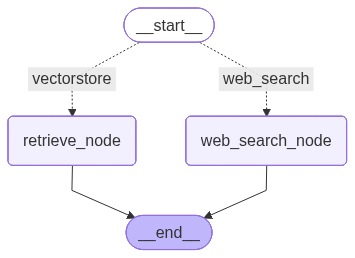

In [183]:
# 그래프 시각화
display(Image(app.get_graph().draw_mermaid_png()))

In [184]:
input = AdaptiveRAGState(
    question = q1
)
rs = app.invoke(input=input)

====[질문분석]====
====[질문 vectorstore로 연결]====
===[문서검색]===
===[검색된 문서 수: 5]===


In [185]:
input = AdaptiveRAGState(
    question = "카카오 AI 이름이 뭐지?"
)
rs = app.invoke(input=input)

====[질문분석]====
====[질문 vectorstore로 연결]====
===[문서검색]===
===[검색된 문서 수: 5]===


#### 테스트2 (문서관련성 체크 + 쿼리 재작성)

In [191]:
# 테스트
## 그래프 베이스 생성
workflow = StateGraph(AdaptiveRAGState)
## 노드 및 엣지 연결
workflow.add_node('retrieve_node', retrieve_node)
workflow.add_node('web_search_node', web_search_node)
workflow.add_conditional_edges(
    START,
    route_question,
    {
        'vectorstore': 'retrieve_node',
        'web_search': 'web_search_node'
    }
)

workflow.add_node('transform_query_node', transform_query_node)
workflow.add_node('retrieval_check_node', retrieval_check_node)
workflow.add_edge('retrieve_node', "retrieval_check_node")
workflow.add_conditional_edges(
    'retrieval_check_node',
    route_retrieval_grade,
    {
        'yes': END,
        'no': "transform_query_node"
    }
)
workflow.add_edge('web_search_node', END)
## 컴파일
app = workflow.compile()

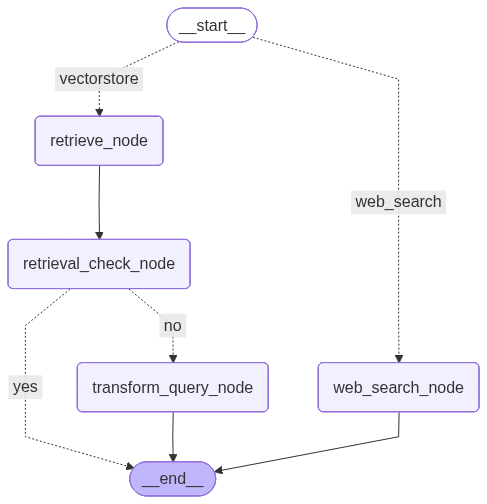

In [192]:
# 그래프 시각화
display(Image(app.get_graph().draw_mermaid_png()))

In [188]:
input = AdaptiveRAGState(
    question = "카카오 AI 이름이 뭐지?"
)
rs = app.invoke(input=input)

====[질문분석]====
====[질문 vectorstore로 연결]====
===[문서검색]===
===[검색된 문서 수: 5]===
====[문서 관련성 체크]====
===[문서갯수 : 3]===


#### 테스트3 (반복구조 생성)

In [215]:
# 테스트
## 그래프 베이스 생성
workflow = StateGraph(AdaptiveRAGState)
## 노드 및 엣지 연결
workflow.add_node('retrieve_node', retrieve_node)
workflow.add_node('web_search_node', web_search_node)
workflow.add_conditional_edges(
    START,
    route_question,
    {
        'vectorstore': 'retrieve_node',
        'web_search': 'web_search_node'
    }
)

workflow.add_node('transform_query_node', transform_query_node)
workflow.add_node('retrieval_check_node', retrieval_check_node)
workflow.add_edge('retrieve_node', "retrieval_check_node")
workflow.add_conditional_edges(
    'retrieval_check_node',
    route_retrieval_grade,
    {
        'yes': END,
        'no': "transform_query_node"
    }
)
workflow.add_edge('transform_query_node', "retrieve_node")
workflow.add_edge('web_search_node', END)
## 컴파일
app = workflow.compile()

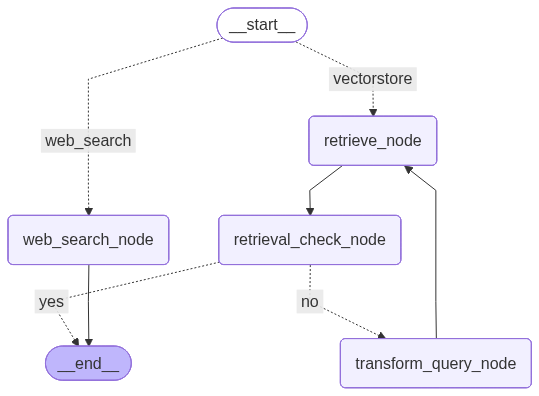

In [216]:
# 그래프 시각화
display(Image(app.get_graph().draw_mermaid_png()))

In [217]:
input = AdaptiveRAGState(
    question = "카카오 AI 이름이 뭐지?"
)
rs = app.invoke(input=input)

====[질문분석]====
====[질문 vectorstore로 연결]====
===[문서검색]===
===[검색된 문서 수: 5]===
====[문서 관련성 체크]====
===[문서갯수 : 3]===


#### 테스트4 (최종답변생성)

In [222]:
# 테스트
## 그래프 베이스 생성
workflow = StateGraph(AdaptiveRAGState)
## 노드 및 엣지 연결
workflow.add_node('retrieve_node', retrieve_node)
workflow.add_node('web_search_node', web_search_node)
workflow.add_conditional_edges(
    START,
    route_question,
    {
        'vectorstore': 'retrieve_node',
        'web_search': 'web_search_node'
    }
)

workflow.add_node('transform_query_node', transform_query_node)
workflow.add_node('retrieval_check_node', retrieval_check_node)
workflow.add_node('generate_answer_node', generate_answer_node)
workflow.add_edge('retrieve_node', "retrieval_check_node")
workflow.add_conditional_edges(
    'retrieval_check_node',
    route_retrieval_grade,
    {
        'yes': "generate_answer_node",
        'no': "transform_query_node"
    }
)
workflow.add_edge('transform_query_node', "retrieve_node")
workflow.add_edge('web_search_node', END)
workflow.add_edge('generate_answer_node', END)
## 컴파일
app = workflow.compile()

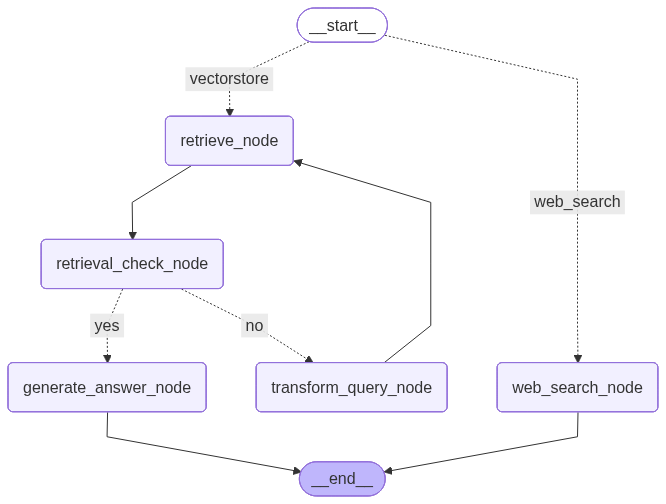

In [223]:
# 그래프 시각화
display(Image(app.get_graph().draw_mermaid_png()))

In [224]:
input = AdaptiveRAGState(
    question = "카카오 AI 이름이 뭐지?",
    max_repeat_num = 2,
    current_repeat_num = 0
)
rs = app.invoke(input=input)

====[질문분석]====
====[질문 vectorstore로 연결]====
===[문서검색]===
===[검색된 문서 수: 5]===
====[문서 관련성 체크]====
===[문서갯수 : 3]===
===[답변생성]===


In [226]:
rs['answer']

'카카오는 최신 AI 서비스 이름으로 ‘카나나(Kanana)’를 발표했습니다.\n\n**Source**\n- 카카오는 대화의 맥락을 기억하여 이용자에게 최적화된 답변을 제공하는 ‘카나나’를 공개했습니다. \n- 카나나는 개인메이트 ‘나나(nana)’와 그룹메이트 ‘카나(kana)’로 구현됩니다. \n- 출처: ./data/SPRi AI Brief_11월호산업동향.pdf (13)'

In [225]:
print(rs['answer'])

카카오는 최신 AI 서비스 이름으로 ‘카나나(Kanana)’를 발표했습니다.

**Source**
- 카카오는 대화의 맥락을 기억하여 이용자에게 최적화된 답변을 제공하는 ‘카나나’를 공개했습니다. 
- 카나나는 개인메이트 ‘나나(nana)’와 그룹메이트 ‘카나(kana)’로 구현됩니다. 
- 출처: ./data/SPRi AI Brief_11월호산업동향.pdf (13)


In [227]:
input = AdaptiveRAGState(
    question = "삼성과 카카오가 만든 생성형 AI 이름은?",
    max_repeat_num = 2,
    current_repeat_num = 0
)
rs = app.invoke(input=input)

====[질문분석]====
====[질문 vectorstore로 연결]====
===[문서검색]===
===[검색된 문서 수: 5]===
====[문서 관련성 체크]====
===[문서갯수 : 2]===
===[답변생성]===


In [228]:
print(rs['answer'])

삼성과 카카오가 만든 생성형 AI 이름은 '카나나'입니다.

**Source**
- 카카오는 통합 AI 브랜드 '카나나'를 발표하였으며, 개인메이트 '나나'와 그룹메이트 '카나'로 구성됩니다. 
- ./data/SPRi AI Brief_11월호산업동향.pdf


#### 테스트5 (할루시네이션 방지)

In [243]:
# 테스트
## 그래프 베이스 생성
workflow = StateGraph(AdaptiveRAGState)
## 노드 및 엣지 연결
workflow.add_node('retrieve_node', retrieve_node)
workflow.add_node('web_search_node', web_search_node)
workflow.add_conditional_edges(
    START,
    route_question,
    {
        'vectorstore': 'retrieve_node',
        'web_search': 'web_search_node'
    }
)

workflow.add_node('transform_query_node', transform_query_node)
workflow.add_node('retrieval_check_node', retrieval_check_node)
workflow.add_node('generate_answer_node', generate_answer_node)
workflow.add_edge('retrieve_node', "retrieval_check_node")
workflow.add_conditional_edges(
    'retrieval_check_node',
    route_retrieval_grade,
    {
        'yes': "generate_answer_node",
        'no': "transform_query_node"
    }
)
workflow.add_edge('transform_query_node', "retrieve_node")

# 할루시네이션 체크 part
workflow.add_node('hallucination_detect_node', hallucination_detect_node)
workflow.add_edge('generate_answer_node', 'hallucination_detect_node')
workflow.add_conditional_edges(
    'hallucination_detect_node',
    route_hallucination_check,
    {
        'yes': "generate_answer_node",
        'no': END
    }
)

workflow.add_edge('web_search_node', END)
## 컴파일
app = workflow.compile()

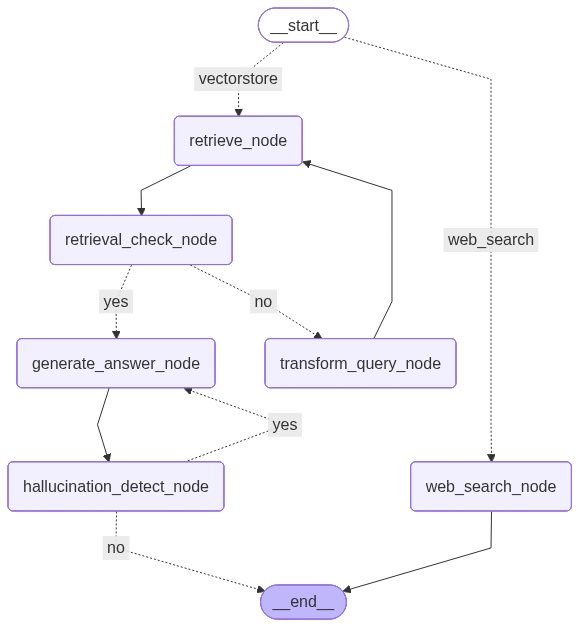

In [244]:
# 그래프 시각화
display(Image(app.get_graph().draw_mermaid_png()))

In [245]:
input = AdaptiveRAGState(
    question = "삼성과 카카오가 만든 생성형 AI 이름은?",
    max_repeat_num = 5,
    current_repeat_num = 0
)
rs = app.invoke(input=input)

====[질문분석]====
====[질문 vectorstore로 연결]====
===[문서검색]===
===[검색된 문서 수: 5]===
====[문서 관련성 체크]====
===[문서갯수 : 2]===
===[답변생성]===
====[할루시네이션 체크]====
===[할루시네이션 감지]===
===[답변생성]===
====[할루시네이션 체크]====
===[할루시네이션 감지]===
===[답변생성]===
====[할루시네이션 체크]====


In [246]:
print(rs['answer'])

삼성이 만든 생성형 AI에 대한 정보는 제공된 맥락에 없습니다. 카카오가 만든 생성형 AI의 이름은 '카나나'입니다.

**Source**
- 카카오는 통합 AI 브랜드 ‘카나나’를 공개했습니다.  
- 카나나는 ‘가장 나다운 AI’를 의미합니다.  
- 카카오는 주요 AI 모델과 신규 서비스의 이름에 카나나를 사용할 계획입니다.  
- ./data/SPRi AI Brief_11월호산업동향.pdf


#### 테스트6 (질문 관련성 확인)

In [253]:
# 테스트
## 그래프 베이스 생성
workflow = StateGraph(AdaptiveRAGState)
## 노드 및 엣지 연결
workflow.add_node('retrieve_node', retrieve_node)
workflow.add_node('web_search_node', web_search_node)
workflow.add_conditional_edges(
    START,
    route_question,
    {
        'vectorstore': 'retrieve_node',
        'web_search': 'web_search_node'
    }
)

workflow.add_node('transform_query_node', transform_query_node)
workflow.add_node('retrieval_check_node', retrieval_check_node)
workflow.add_node('generate_answer_node', generate_answer_node)
workflow.add_edge('retrieve_node', "retrieval_check_node")
workflow.add_conditional_edges(
    'retrieval_check_node',
    route_retrieval_grade,
    {
        'yes': "generate_answer_node",
        'no': "transform_query_node"
    }
)
workflow.add_edge('transform_query_node', "retrieve_node")

workflow.add_node('hallucination_detect_node', hallucination_detect_node)
workflow.add_edge('generate_answer_node', 'hallucination_detect_node')
workflow.add_conditional_edges(
    'hallucination_detect_node',
    route_hallucination_check,
    {
        'yes': "generate_answer_node",
        'no': "relevant_detect_node"
    }
)
# 답변 관련성 체크 Part
workflow.add_node('relevant_detect_node', relevant_detect_node)
workflow.add_conditional_edges(
    'relevant_detect_node',
    route_relevant_check,
    {
        'yes': END,
        'no': "transform_query_node"
    }
)

workflow.add_edge('web_search_node', END)
## 컴파일
app = workflow.compile()

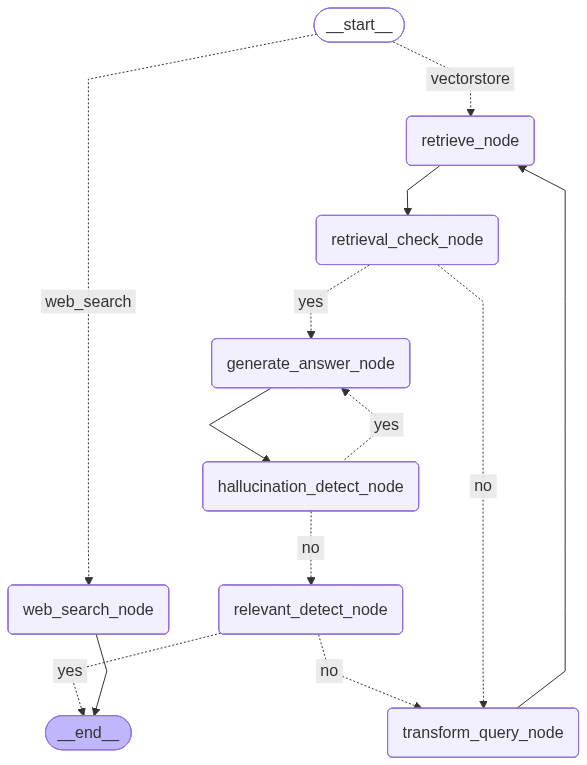

In [254]:
# 그래프 시각화
display(Image(app.get_graph().draw_mermaid_png()))

In [255]:
input = AdaptiveRAGState(
    question = "삼성과 카카오가 만든 생성형 AI 이름은?",
    max_repeat_num = 5,
    current_repeat_num = 0
)
rs = app.invoke(input=input)

====[질문분석]====
====[질문 vectorstore로 연결]====
===[문서검색]===
===[검색된 문서 수: 5]===
====[문서 관련성 체크]====
===[문서갯수 : 2]===
===[답변생성]===
====[할루시네이션 체크]====
====[답변관련성 체크]====
===[답변관련성 문제 감지]===


KeyError: 'relevant_score'

In [ ]:
print(rs['answer'])